        Date     Glucose
0 2025-01-01  123.973713
1 2025-01-02  119.983695
2 2025-01-03  127.315694
3 2025-01-04  135.273919
4 2025-01-05  122.043502


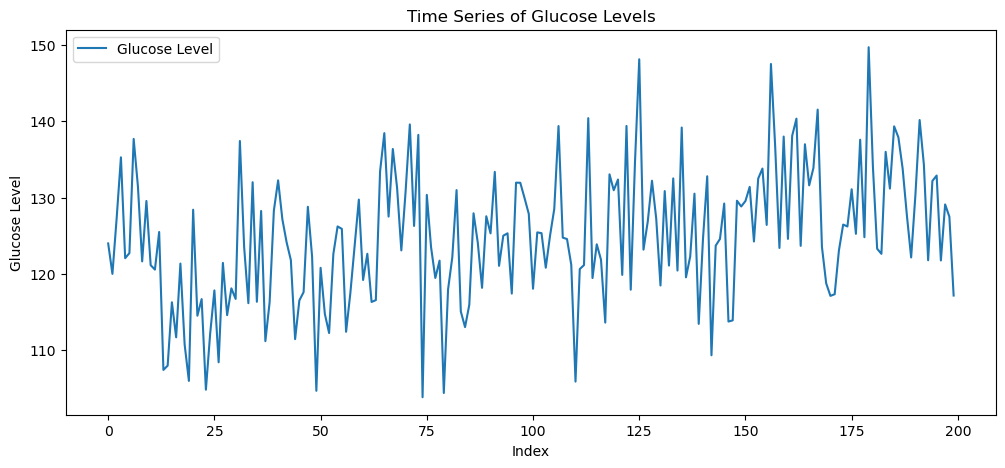

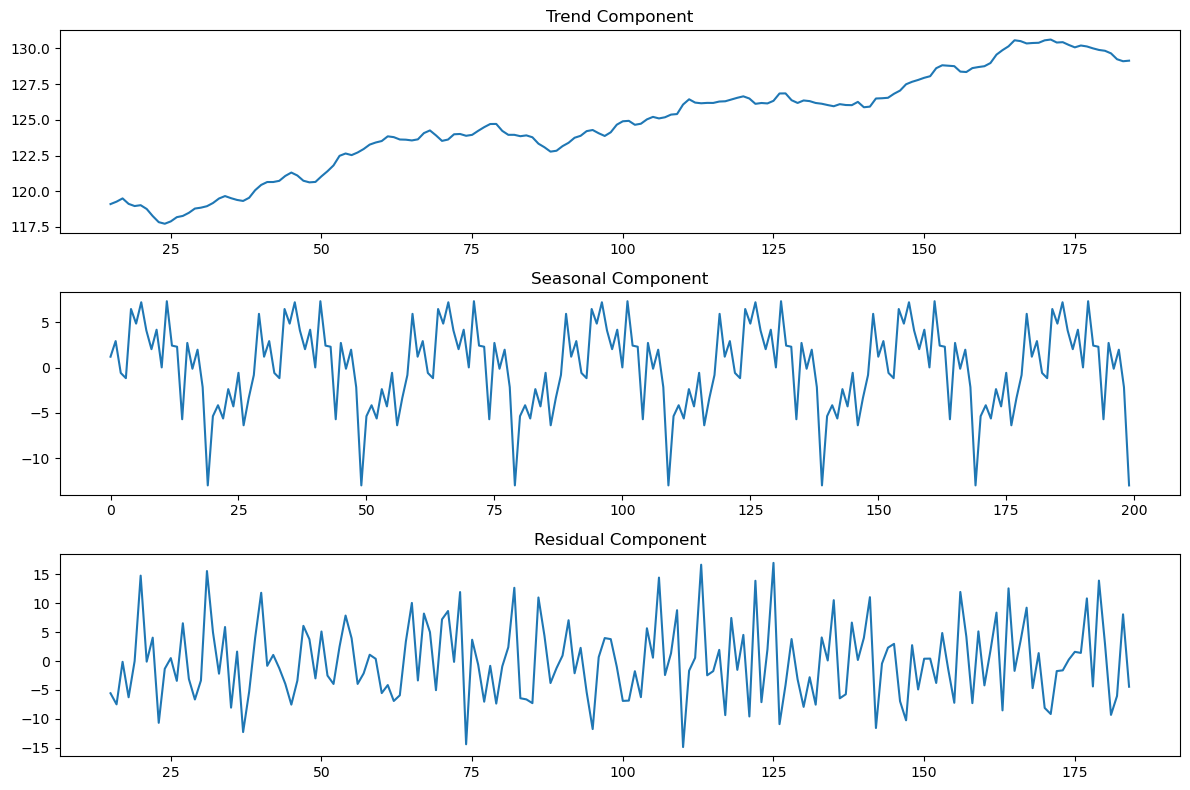

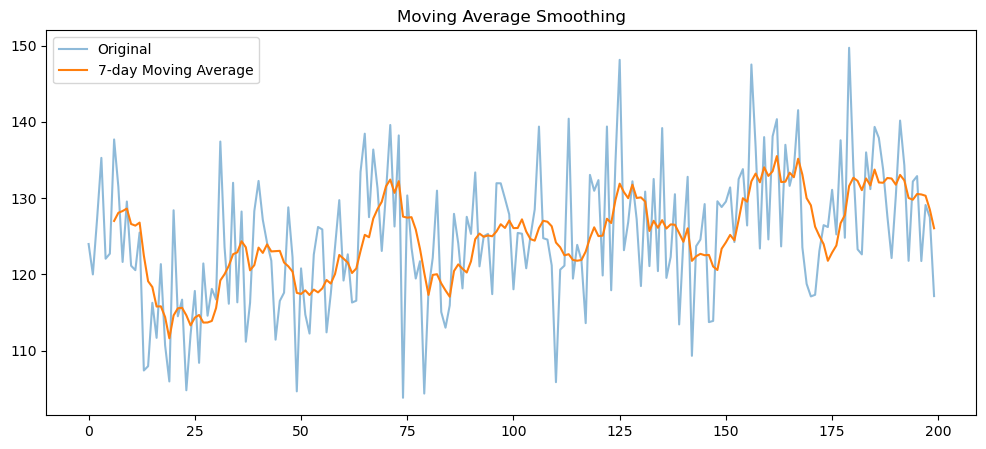

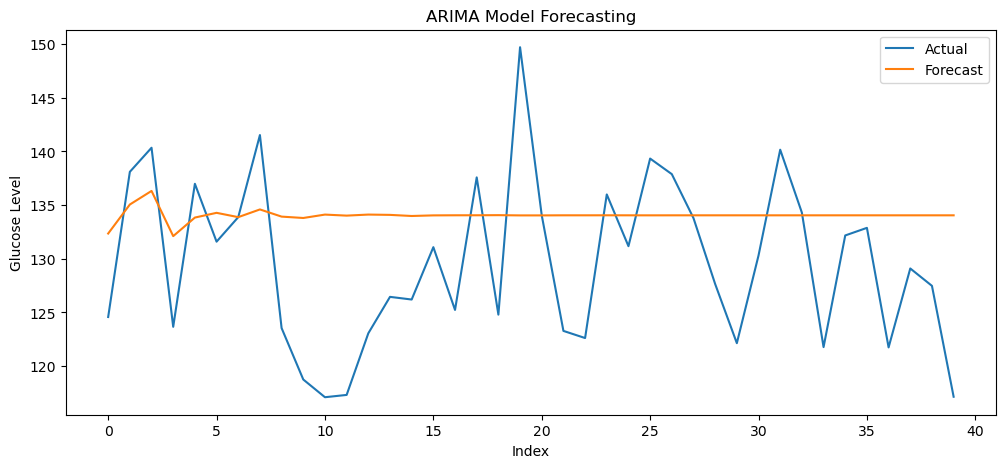

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)

n = 200

dates = pd.date_range(start="2025-01-01", periods=n, freq="D")

trend = np.linspace(0, 10, n)
seasonality = 5 * np.sin(2 * np.pi * np.arange(n) / 30)
noise = np.random.normal(0, 8, n)

glucose = 120 + trend + seasonality + noise

diabetes_data = pd.DataFrame({
    "Date": dates,
    "Glucose": glucose
})

diabetes_data.to_csv("diabetes9.csv", index=False)

print(diabetes_data.head())

plt.figure(figsize=(12, 5))
plt.plot(diabetes_data["Glucose"], label="Glucose Level")
plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("Time Series of Glucose Levels")
plt.legend()
plt.show()

decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=30
)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

decomposition.trend.plot(ax=axes[0], title="Trend Component")
decomposition.seasonal.plot(ax=axes[1], title="Seasonal Component")
decomposition.resid.plot(ax=axes[2], title="Residual Component")

plt.tight_layout()
plt.show()

diabetes_data["Glucose_MA"] = diabetes_data["Glucose"].rolling(
    window=7
).mean()

plt.figure(figsize=(12, 5))
plt.plot(
    diabetes_data["Glucose"],
    label="Original",
    alpha=0.5
)
plt.plot(
    diabetes_data["Glucose_MA"],
    label="7-day Moving Average"
)
plt.legend()
plt.title("Moving Average Smoothing")
plt.show()

train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

model = ARIMA(train, order=(5, 1, 0))
fitted_model = model.fit()

forecast = fitted_model.forecast(steps=len(test))

plt.figure(figsize=(12, 5))
plt.plot(
    range(len(test)),
    test,
    label="Actual"
)
plt.plot(
    range(len(test)),
    forecast,
    label="Forecast"
)
plt.xlabel("Index")
plt.ylabel("Glucose Level")
plt.title("ARIMA Model Forecasting")
plt.legend()
plt.show()